# Вариант 4


# Анализ данных о мобильных телефонах


## Импорты и параметры


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, median_test, chisquare

plt.style.use('default')
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 10

ALPHA = 0.05


## Загрузка данных

In [80]:
df = pd.read_csv('./mobile_phones.csv')

print(f"Размер датасета:")
print(df.shape, "\n")

print("Информация о столбцах:")
print(df.info(), "\n")

print("Описательная статистика:")
print(df.describe(), "\n")


Размер датасета:
(2000, 21) 

Информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17 

## -------------------------------------------------------------------


# Задача 1: Проверка предположения о законе распределения емкости аккумулятора


## Посмотрим на распределение емкостей аккамулятора


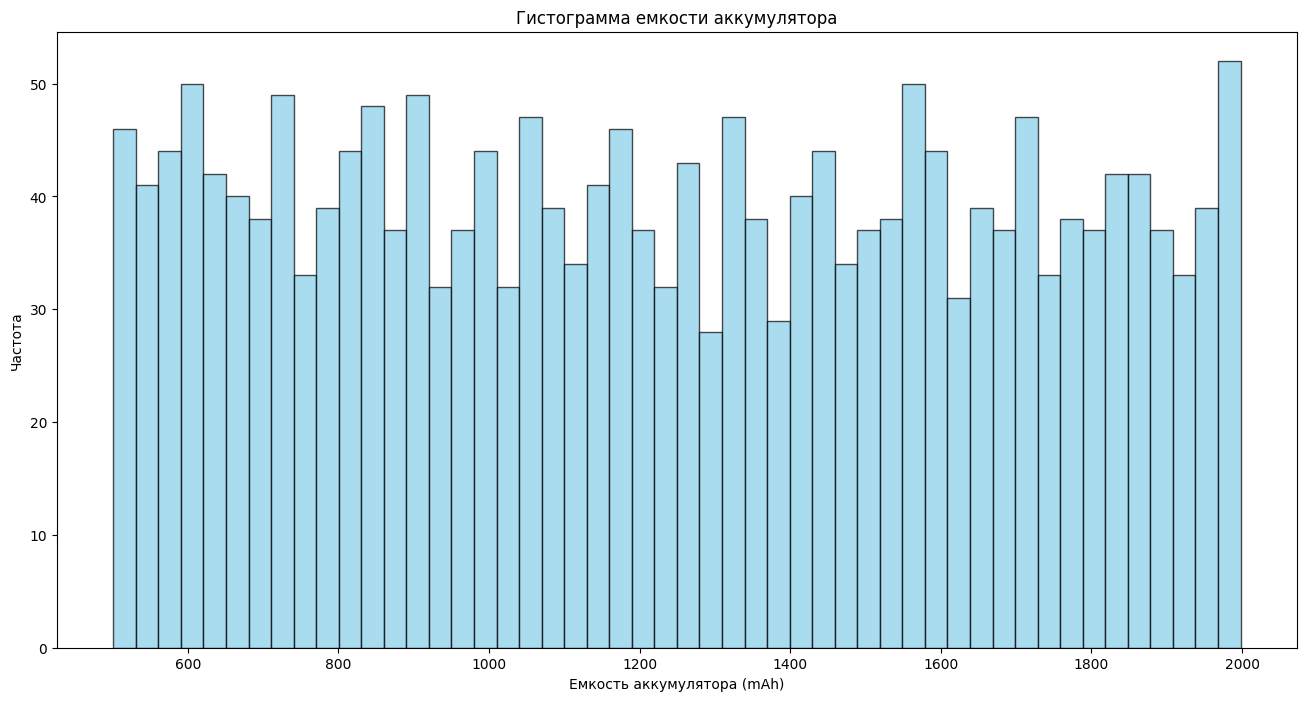

In [81]:
battery_power = df['battery_power']

plt.subplot(1, 1, 1)
plt.hist(battery_power, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Гистограмма емкости аккумулятора')
plt.xlabel('Емкость аккумулятора (mAh)')
plt.ylabel('Частота')
plt.show()


## Тест 1.1: Критерий Колмогорова-Смирнова (handwritten)

Формулировка гипотез:

- H0: Емкость аккумулятора распределена равномерно на интервале [min, max]

- H1: Емкость аккумулятора не распределена равномерно

Статистика критерия:
D = max|Fn(x) - F0(x)|, где Fn(x) - эмпирическая функция распределения, F0(x) - теоретическая


In [82]:
def ks_test_uniform(data):
    n = len(data)
    data_sorted = np.sort(data)
    # Параметры равномерного распределения
    a, b = data.min(), data.max()
    # Теоретическая функция распределения (равномерное распределение)
    def F0(x):
        return (x - a) / (b - a)
    # Вычисление статистики D
    D = 0
    for i, x in enumerate(data_sorted):
        fn_x = (i + 1) / n
        f0_x = F0(x)
        D = max(D, abs(fn_x - f0_x))
    # Критическое значение (приближение для больших выборок)
    critical_value = 1.36 / np.sqrt(n)
    # p-value (приближение)
    if D == 0:
        return 0.0, critical_value, 1.0
    # Используем приближение Смирнова
    lambda_val = np.sqrt(n) * D
    # Приближение для p-value
    p_value = 2 * np.exp(-2 * lambda_val**2)
    p_value = min(p_value, 1.0)
    return D, critical_value, p_value

D, critical_value, p_value = ks_test_uniform(battery_power)

print(f"D: {D:.6f}")
print(f"Критическое значение D: {critical_value:.6f}", "\n")

print(f"p-value: {p_value:.6f}")
print(f"alpha: {ALPHA:.6e}")

assert D <= critical_value, "Не должны отвергать H0"

assert p_value >= ALPHA, "Не должны отвергать H0"


D: 0.020771
Критическое значение D: 0.030411 

p-value: 0.356091
alpha: 5.000000e-02


## Тест 1.2: Критерий хи-квадрат Пирсона (library)


In [83]:
# Нормализуем данные для стандартного равномерного распределения U(0,1)
battery_normalized = (battery_power - battery_power.min()) / (battery_power.max() - battery_power.min())

# Разбиваем данные на интервалы
n_bins = 50
observed_freq, bin_edges = np.histogram(battery_normalized, bins=n_bins, range=(0, 1))

# Ожидаемая частота для равномерного распределения
expected_freq = len(battery_normalized) / n_bins

# Критерий хи-квадрат
chi2_stat, chi2_p_value = chisquare(observed_freq, f_exp=[expected_freq] * n_bins)

print(f"Статистика χ^2: {chi2_stat:.6f}", "\n")

print(f"p-value: {chi2_p_value:.6f}")
print(f"alpha: {ALPHA:.6e}")

assert chi2_p_value >= ALPHA, "Не должны отвергать H0"


Статистика χ^2: 43.300000 

p-value: 0.702526
alpha: 5.000000e-02


## Дополнительные визуализации


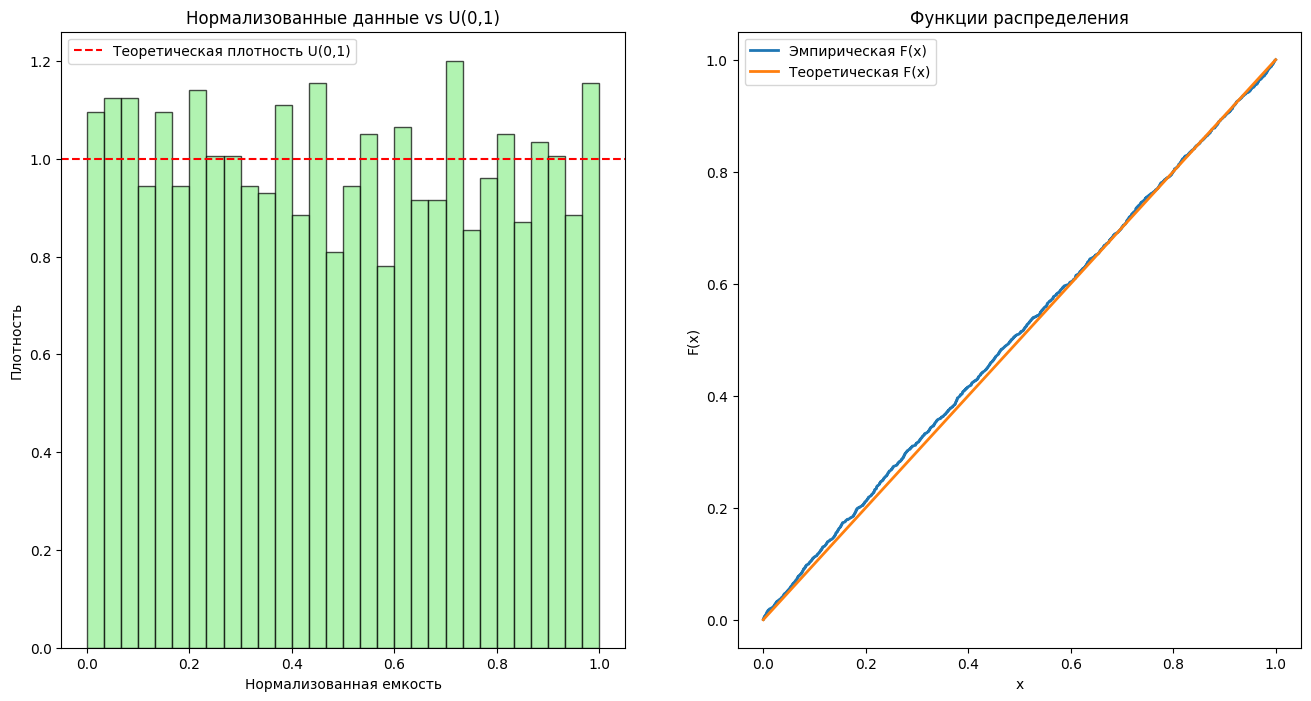

In [84]:
plt.subplot(1, 2, 1)
plt.hist(battery_normalized, bins=30, alpha=0.7, color='lightgreen', edgecolor='black', density=True)
plt.axhline(y=1, color='red', linestyle='--', label='Теоретическая плотность U(0,1)')
plt.title('Нормализованные данные vs U(0,1)')
plt.xlabel('Нормализованная емкость')
plt.ylabel('Плотность')
plt.legend()

# Сравнение эмпирической и теоретической функций распределения
x_sorted = np.sort(battery_normalized)
y_empirical = np.arange(1, len(x_sorted) + 1) / len(x_sorted)
y_theoretical = x_sorted

plt.subplot(1, 2, 2)
plt.plot(x_sorted, y_empirical, label='Эмпирическая F(x)', linewidth=2)
plt.plot(x_sorted, y_theoretical, label='Теоретическая F(x)', linewidth=2)
plt.title('Функции распределения')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.legend()

plt.show()


# Задача 1: Выводы

Основываясь на визуализации и статистиках, выдвигаем гипотезу, что емкость аккумулятора распределена равномерно, так как:
- Гистограмма показывает примерно равномерное распределение значений
- Отсутствуют явные пики или провалы
- Данные покрывают диапазон от минимума до максимума довольно равномерно
- Оба статистических теста подтверждают наблюдения


## -------------------------------------------------------------------


# Задача 2: Сравнение распределений емкости аккумулятора для телефонов с Wi-Fi и без Wi-Fi

Проверим, одинаково ли распределена емкость аккумулятора среди телефонов, поддерживающих и не поддерживающих Wi-Fi.

In [85]:
wifi_group = df[df['wifi'] == 1]['battery_power']
no_wifi_group = df[df['wifi'] == 0]['battery_power']


## Визуализация


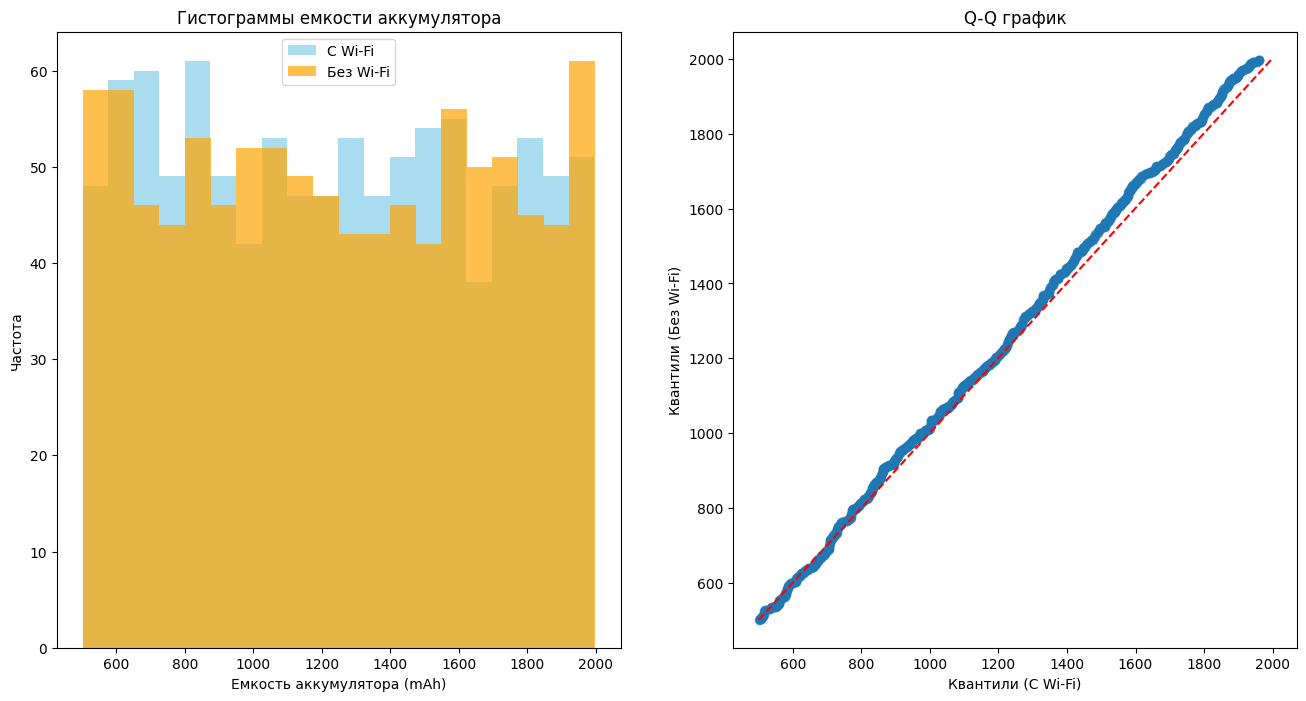

In [86]:
plt.subplot(1, 2, 1)
plt.hist(wifi_group, bins=20, alpha=0.7, label='С Wi-Fi', color='skyblue')
plt.hist(no_wifi_group, bins=20, alpha=0.7, label='Без Wi-Fi', color='orange')
plt.title('Гистограммы емкости аккумулятора')
plt.xlabel('Емкость аккумулятора (mAh)')
plt.ylabel('Частота')
plt.legend()

plt.subplot(1, 2, 2)
wifi_quantiles = np.percentile(wifi_group, np.linspace(0, 100, len(wifi_group)))
no_wifi_quantiles = np.percentile(no_wifi_group, np.linspace(0, 100, len(no_wifi_group)))
min_len = min(len(wifi_quantiles), len(no_wifi_quantiles))
plt.scatter(wifi_quantiles[:min_len], no_wifi_quantiles[:min_len], alpha=0.6)
plt.plot([min(wifi_quantiles), max(wifi_quantiles)], [min(no_wifi_quantiles), max(no_wifi_quantiles)], 'r--')
plt.xlabel('Квантили (С Wi-Fi)')
plt.ylabel('Квантили (Без Wi-Fi)')
plt.title('Q-Q график')

plt.show()


## Тест 2.1: Критерий Манна-Уитни (handwritten)

Формулировка гипотез:

- H0: Распределения емкости аккумулятора в группах с Wi-Fi и без Wi-Fi одинаковы

- H1: Распределения различаются

Статистика критерия:
U = min(U1, U2), где U1 и U2 это ранговые суммы для каждой группы


In [87]:
def mann_whitney_test(X, Y):
    n1, n2 = len(X), len(Y)
    # Объединяем выборки и присваиваем ранги
    combined = np.concatenate([X, Y])
    ranks = stats.rankdata(combined)
    # Сумма рангов первой выборки
    R1 = np.sum(ranks[:n1])
    # Сумма рангов второй выборки
    R2 = np.sum(ranks[n1:])
    # Статистики U
    U1 = R1 - n1 * (n1 + 1) / 2
    U2 = R2 - n2 * (n2 + 1) / 2
    U = min(U1, U2)
    # Средние и дисперсия под H0
    mu_U = n1 * n2 / 2
    sigma_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    # Z-статистика (для больших выборок распределение U стремится к нормальному)
    Z = (U - mu_U) / sigma_U
    p_value = 2 * (1 - stats.norm.cdf(abs(Z)))
    return {
        'U': U, 
        'Z': Z,
        'p_value': p_value,
    }

result = mann_whitney_test(wifi_group.values, no_wifi_group.values)

print(f"U = min(U1, U2): {result['U']:.6f}")
print(f"Z = (U - mu_U) / sigma_U: {result['Z']:.6f}", "\n")

print(f"p-value: {result['p_value']:.6f}")
print(f"alpha: {ALPHA:.6e}")

assert result['p_value'] >= ALPHA, "Не должны отвергать H0"


U = min(U1, U2): 495016.000000
Z = (U - mu_U) / sigma_U: -0.378410 

p-value: 0.705126
alpha: 5.000000e-02


## Тест 2.2: Медианный тест (library)


In [88]:
median_stat, median_p_value, median_grand, contingency_table = median_test(wifi_group, no_wifi_group)

print(f"Общая медиана: {median_grand:.6f}", "\n")

print(f"p-value: {median_p_value:.6f}")
print(f"alpha: {ALPHA:.6e}")

assert float(median_p_value) >= ALPHA, "Не должны отвергать H0" # type: ignore


Общая медиана: 1226.000000 

p-value: 0.687293
alpha: 5.000000e-02


# Задача 2: Выводы

Отсутствуют статистически значимые различия в распределении емкости аккумулятора между телефонами с поддержкой Wi-Fi и без неё (p > 0.05).

- Наличие Wi-Fi не влияет на емкость аккумулятора - различия в средних значениях (~7 mAh) статистически незначимы
- Производители не меняют емкость аккумулятора в зависимости от наличия Wi-Fi модуля
- Оба статистических теста подтверждают гипотезу


## -------------------------------------------------------------------


# Задача 3: Проверка связи между емкостью аккумулятора и ценой

Проверим, растет ли цена при увеличении емкости аккумулятора. Используем корреляционный анализ.

## Визуализация


Емкость аккумулятора: среднее = 1238.52, стд = 439.42
Ценовой диапазон: среднее = 1.50, стд = 1.12
Корреляция Пирсона: 0.200723


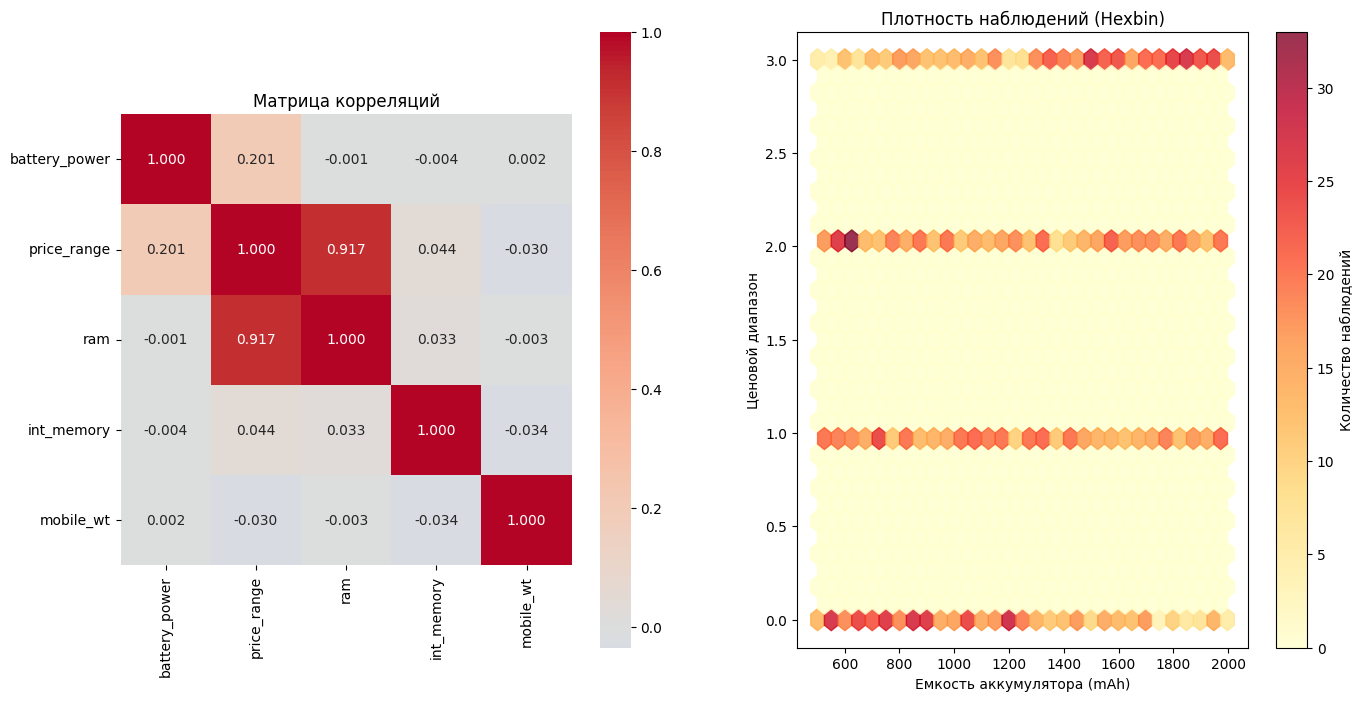

In [89]:
price = df['price_range']

print(f"Емкость аккумулятора: среднее = {battery_power.mean():.2f}, стд = {battery_power.std():.2f}")
print(f"Ценовой диапазон: среднее = {price.mean():.2f}, стд = {price.std():.2f}")
print(f"Корреляция Пирсона: {battery_power.corr(price):.6f}")

# График 1: Heatmap корреляции (добавим другие переменные для контекста)
ax2 = plt.subplot(1, 2, 1)
numeric_cols = ['battery_power', 'price_range', 'ram', 'int_memory', 'mobile_wt']
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=ax2, square=True, fmt='.3f')
ax2.set_title('Матрица корреляций')

# График 2: Hexbin plot (плотность точек)
ax3 = plt.subplot(1, 2, 2)
hb = ax3.hexbin(battery_power, price, gridsize=30, cmap='YlOrRd', alpha=0.8)
ax3.set_xlabel('Емкость аккумулятора (mAh)')
ax3.set_ylabel('Ценовой диапазон')
ax3.set_title('Плотность наблюдений (Hexbin)')
plt.colorbar(hb, ax=ax3, label='Количество наблюдений')

plt.show()


## Тест 3.1: Проверка значимости корреляции Спирмена (handwritten)

Формулировка гипотез:
- H0: ρ == 0 (корреляция между емкостью аккумулятора и ценой равна нулю)
- H1: ρ != 0 (корреляция отлична от нуля)

Статистика критерия:
t = r*sqrt(n-2)/sqrt(1-r^2), где r это выборочный коэффициент корреляции


In [90]:
def spearman_correlation_test(x, y, alpha=0.05):
    n = len(x)

    # Преобразуем данные в ранги
    rank_x = stats.rankdata(x)
    rank_y = stats.rankdata(y)

    # Вычисляем корреляцию Спирмена через формулу с разностями рангов
    d = rank_x - rank_y
    d_squared = d ** 2
    sum_d_squared = np.sum(d_squared)

    # Формула Спирмена
    rho = 1 - (6 * sum_d_squared) / (n * (n**2 - 1))

    # t-статистика для проверки значимости
    if abs(rho) == 1:
        t_stat = np.inf if rho > 0 else -np.inf
    else:
        t_stat = rho * np.sqrt(n - 2) / np.sqrt(1 - rho**2)

    # Критическое значение и p-value
    df = n - 2

    critical_value = stats.t.ppf(1 - alpha/2, df)
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))

    return rho, t_stat, critical_value, p_value

rho, t_stat, critical_value, p_value = spearman_correlation_test(battery_power, price, ALPHA)

t_stat = abs(t_stat)

print(f"Выборочная корреляция Спирмена: {rho:.6f}", "\n")

print(f"t-статистика: {t_stat:.6f}")
print(f"Критическое значение: {critical_value:.6f}", "\n")

print(f"p-value: {p_value:.6e}")
print(f"alpha: {ALPHA:.6e}")

assert t_stat > critical_value and rho > 0, "Должны отвергать H0"

assert p_value < ALPHA, "Должны отвергать H0"


Выборочная корреляция Спирмена: 0.224891 

t-статистика: 10.316668
Критическое значение: 1.961152 

p-value: 0.000000e+00
alpha: 5.000000e-02


## Тест 3.2: Корреляция Пирсона (library)


In [91]:
pearson_r, pearson_p = pearsonr(battery_power, price)

print(f"Корреляция Пирсона: {pearson_r:.6f}", "\n")

print(f"p-value: {pearson_p:.6e}")
print(f"alpha: {ALPHA:.6e}")

assert pearson_p < ALPHA, "Должны отвергать H0" # type: ignore


Корреляция Пирсона: 0.200723 

p-value: 1.264854e-19
alpha: 5.000000e-02


# Задача 3: Выводы

Есть статистически значимая (но не сильная) положительная связь между емкостью аккумулятора и ценой (p < 0.001)

- Слабая корреляция: только ~4% (r^2 = ~0.04) вариации цены объясняется емкостью батареи
- С ростом емкости аккумулятора цена увеличивается, но это не основной ценообразующий фактор
- Емкость влияет на цену, но слабо, есть множество других важных характеристик
- Оба статистических теста подтверждают выводы
